### Logistic regression and Maximum Likelihood Exstimation

In [166]:
import pandas as pd

df = pd.read_csv("../Data/Heart_Disease_Prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


#### Exercise
For this exercise, we will choose the column 'Heart Disease' as our response variable. The classification is a binary problem, 'present' och 'absent'. 

In this dataset, there are several categorical variables. The dataset is from Kaggle: https://www.kaggle.com/datasets/neurocipher/heartdisease

Investigate the following imports and use them to solve the exercise.

In [167]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

a) One-hot encode categorical data in the dataframe. The response, "Heart Disease", also need encoding. Use pandas for these encodings for convenience, or code them manually if you're up for it! Many columns in this problem are categorical.

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [169]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [170]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


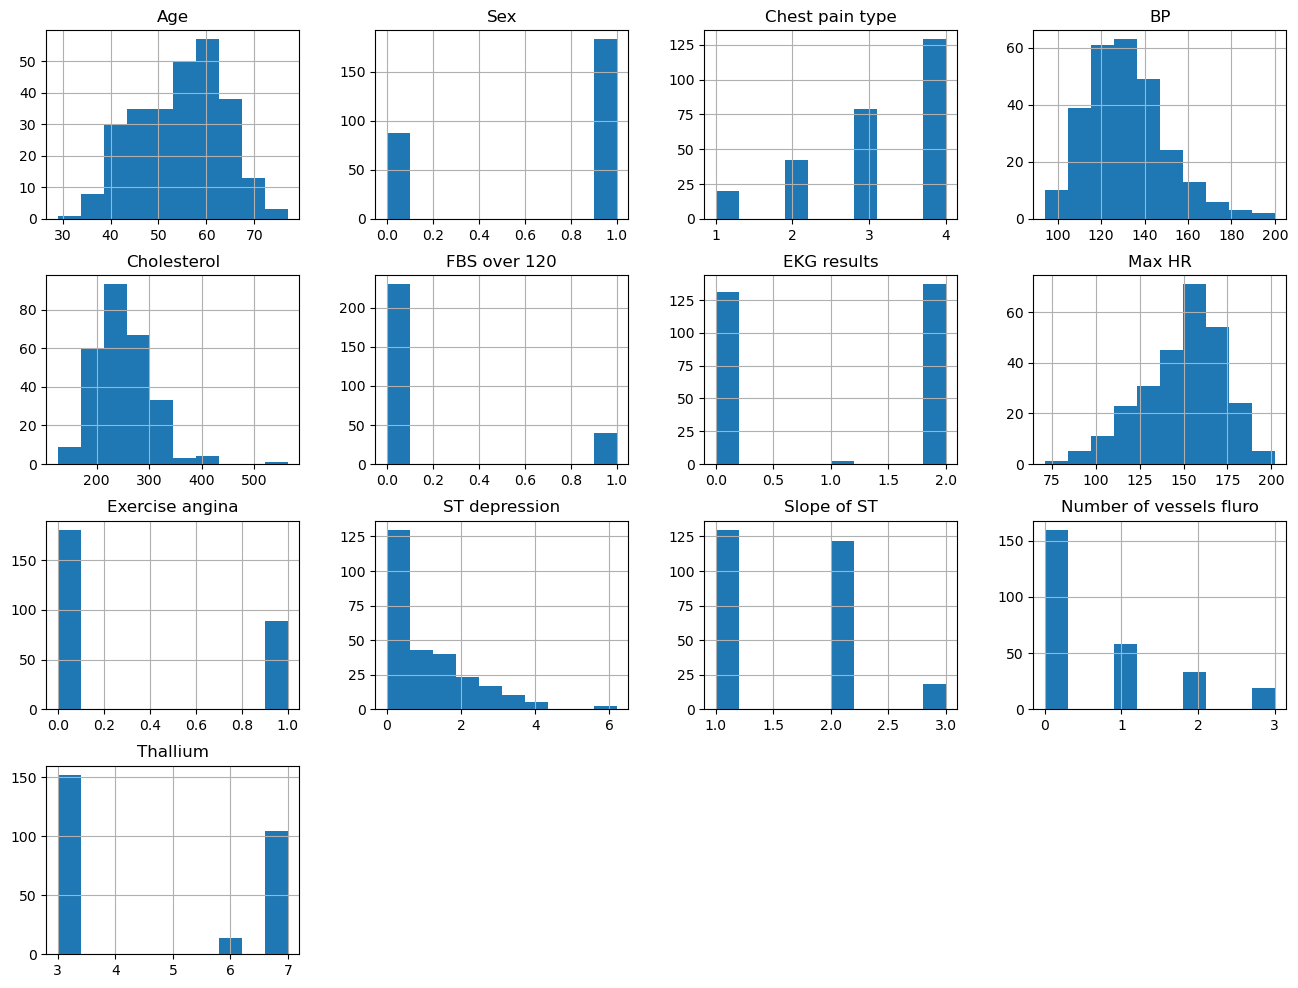

In [171]:
df.hist(figsize=(16,12));

In [172]:
df.drop("Heart Disease", axis=1).corr()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Age,1.000000,-0.094401,0.096920,0.273053,0.220056,0.123458,0.128171,-0.402215,0.098297,0.194234,0.159774,0.356081,0.106100
Sex,-0.094401,1.000000,0.034636,-0.062693,-0.201647,0.042140,0.039253,-0.076101,0.180022,0.097412,0.050545,0.086830,0.391046
Chest pain type,0.096920,0.034636,1.000000,-0.043196,0.090465,-0.098537,0.074325,-0.317682,0.353160,0.167244,0.136900,0.225890,0.262659
BP,0.273053,-0.062693,-0.043196,1.000000,0.173019,0.155681,0.116157,-0.039136,0.082793,0.222800,0.142472,0.085697,0.132045
Cholesterol,0.220056,-0.201647,0.090465,0.173019,1.000000,0.025186,0.167652,-0.018739,0.078243,0.027709,-0.005755,0.126541,0.028836
FBS over 120,0.123458,0.042140,-0.098537,0.155681,0.025186,1.000000,0.053499,0.022494,-0.004107,-0.025538,0.044076,0.123774,0.049237
EKG results,0.128171,0.039253,0.074325,0.116157,0.167652,0.053499,1.000000,-0.074628,0.095098,0.120034,0.160614,0.114368,0.007337
Max HR,-0.402215,-0.076101,-0.317682,-0.039136,-0.018739,0.022494,-0.074628,1.000000,-0.380719,-0.349045,-0.386847,-0.265333,-0.253397
Exercise angina,0.098297,0.180022,0.353160,0.082793,0.078243,-0.004107,0.095098,-0.380719,1.000000,0.274672,0.255908,0.153347,0.321449
ST depression,0.194234,0.097412,0.167244,0.222800,0.027709,-0.025538,0.120034,-0.349045,0.274672,1.000000,0.609712,0.255005,0.324333


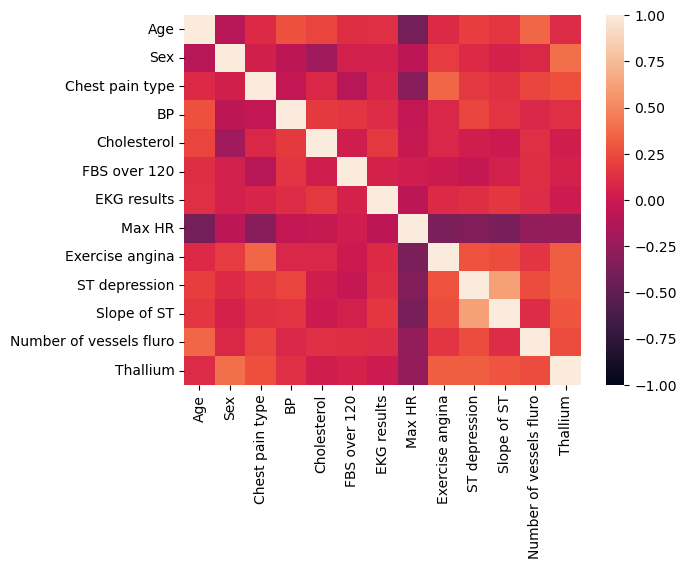

In [173]:
import seaborn as sns

sns.heatmap(df.drop("Heart Disease", axis=1).corr(), vmin=-1);


In [174]:
df = pd.get_dummies(df, columns=["Heart Disease"], drop_first=True) # dummy
df = pd.get_dummies(df, columns=["Sex", "Chest pain type", "FBS over 120", "EKG results", "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"], drop_first=False) # one-hot
df.head()

,Age,BP,Cholesterol,Max HR,ST depression,Heart Disease_Presence,Sex_0,Sex_1,Chest pain type_1,Chest pain type_2,...,Slope of ST_1,Slope of ST_2,Slope of ST_3,Number of vessels fluro_0,Number of vessels fluro_1,Number of vessels fluro_2,Number of vessels fluro_3,Thallium_3,Thallium_6,Thallium_7
0,70,130,322,109,2.4,True,False,True,False,False,...,False,True,False,False,False,False,True,True,False,False
1,67,115,564,160,1.6,False,True,False,False,False,...,False,True,False,True,False,False,False,False,False,True
2,57,124,261,141,0.3,True,False,True,False,True,...,True,False,False,True,False,False,False,False,False,True
3,64,128,263,105,0.2,False,False,True,False,False,...,False,True,False,False,True,False,False,False,False,True
4,74,120,269,121,0.2,False,True,False,False,True,...,True,False,False,False,True,False,False,True,False,False


b) Create a train/test split. We won't use a validation set for this problem, since we aren't refining the results anyhow.

c) Scale and center the data. Use StandardScaler from sklearn, or use the _standardization_ statistic $\frac{x-\bar{x}}{S}$ on the <em>training</em>data. Use the _same_ values to standardize the test data (note that this may give values outside the standardized range: this is the entire point). For sklearn this means using `fit_transform` on the training data but _only_ `transform` on the test data. If you calculate yourself, $\bar{x}$ and $S$ are calculated on the trainingdata and then applied also to the testdata -- don't recalculate the standardization statistic for the testdata, but use the same values as calculated on the trainingdata for $\bar{x}$ and $S$. 

In [175]:
X, y = df.drop(["Heart Disease_Presence", "Max HR"], axis=1), df["Heart Disease_Presence"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

d) Use LogisticRegression from sklearn and fit a regression to the scaled training data.

In [176]:
model = LogisticRegression(penalty='l2')
model.fit(scaled_X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


e) Investigate the below imports and use them to produce a Confusion Matrix and a classification report.

              precision    recall  f1-score   support

       False       0.86      0.93      0.89        54
        True       0.88      0.78      0.82        36

    accuracy                           0.87        90
   macro avg       0.87      0.85      0.86        90
weighted avg       0.87      0.87      0.87        90



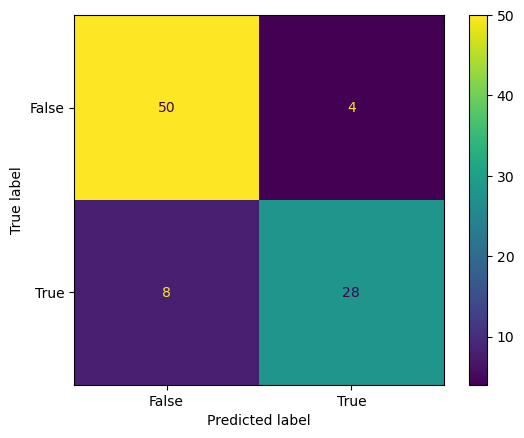

In [177]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = model.predict(scaled_X_test)

report = classification_report(y_test, y_pred)
print(report)
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
displ = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
displ.plot()